# Loan Default Prediction — Exploratory Data Analysis

This notebook covers:
- Loading data with memory optimization for 8GB RAM
- Target variable and class imbalance analysis
- Missing value analysis
- Key feature distributions
- External credit score analysis
- Categorical feature analysis
- Supplementary table summaries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8')

def reduce_memory(df):
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')
    return df

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load main application table with memory optimization
app_train = reduce_memory(pd.read_csv('../data/raw/application_train.csv'))
app_test = reduce_memory(pd.read_csv('../data/raw/application_test.csv'))

print(f"Training set: {app_train.shape[0]:,} rows  {app_train.shape[1]} cols  "
      f"{app_train.memory_usage().sum()/1e6:.1f} MB")
print(f"Test set:     {app_test.shape[0]:,} rows  {app_test.shape[1]} cols  "
      f"{app_test.memory_usage().sum()/1e6:.1f} MB")

gc.collect()
print("\nData loaded successfully")

Training set: 307,511 rows  122 cols  135.6 MB
Test set:     48,744 rows  121 cols  21.4 MB

Data loaded successfully


Target distribution:
  No default (0): 282,686 (91.9%)
  Default    (1): 24,825 (8.1%)

Class imbalance ratio: 11.4:1


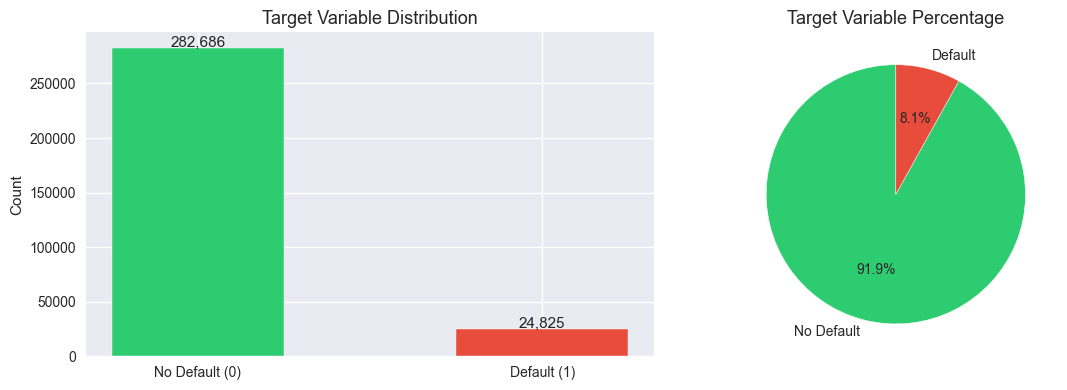

Plot saved to reports/


In [4]:
# Target variable analysis
target_counts = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True) * 100

print("Target distribution:")
print(f"  No default (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"  Default    (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print(f"\nClass imbalance ratio: {target_counts[0]/target_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['No Default (0)', 'Default (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Target Variable Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

axes[1].pie(target_counts.values, labels=['No Default', 'Default'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Target Variable Percentage', fontsize=13)

plt.tight_layout()
plt.savefig('../reports/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/")

Total columns with missing values: 67
Columns with >50% missing:         41
Columns with >20% missing:         50

Top 10 columns by missing %:
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865       69.872
COMMONAREA_MODE                  214865       69.872
COMMONAREA_AVG                   214865       69.872
NONLIVINGAPARTMENTS_MODE         213514       69.433
NONLIVINGAPARTMENTS_MEDI         213514       69.433
NONLIVINGAPARTMENTS_AVG          213514       69.433
FONDKAPREMONT_MODE               210295       68.386
LIVINGAPARTMENTS_AVG             210199       68.355
LIVINGAPARTMENTS_MEDI            210199       68.355
LIVINGAPARTMENTS_MODE            210199       68.355


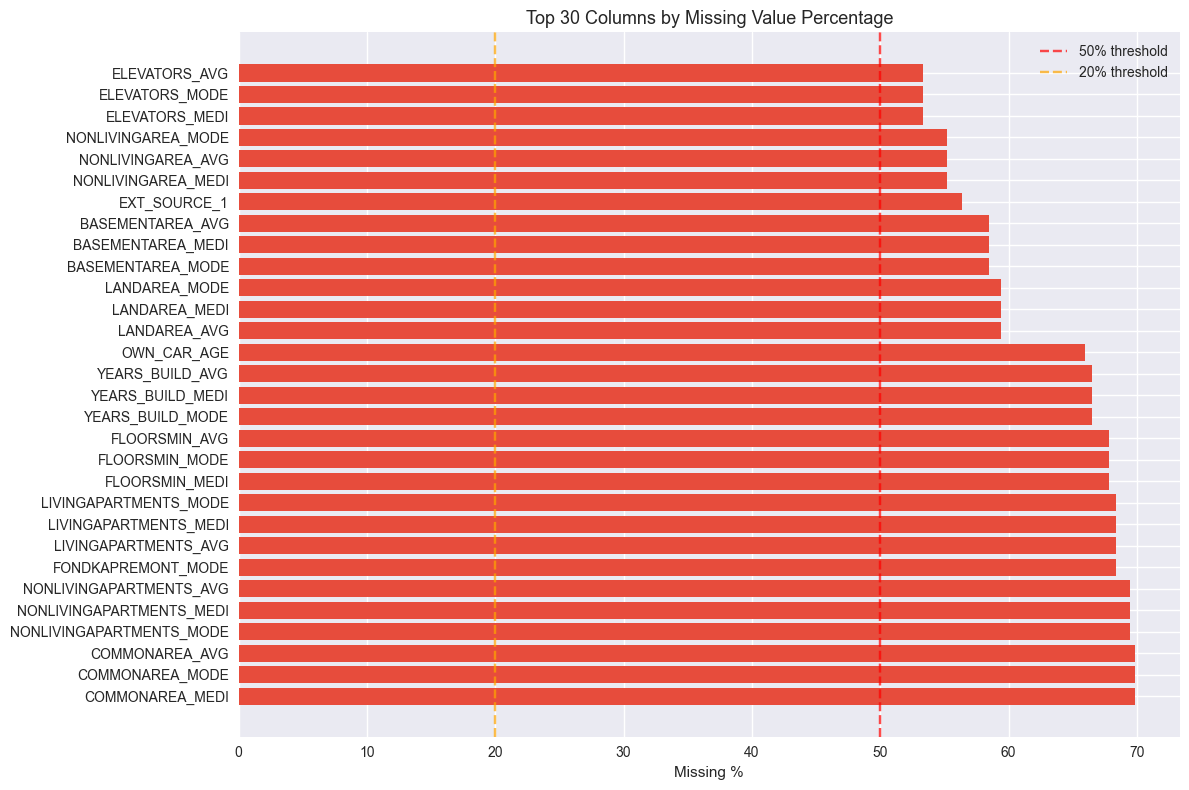

Plot saved to reports/


In [5]:
# Missing value analysis
missing = app_train.isnull().sum()
missing_pct = (missing / len(app_train)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f"Total columns with missing values: {len(missing_df)}")
print(f"Columns with >50% missing:         {len(missing_df[missing_df['missing_pct'] > 50])}")
print(f"Columns with >20% missing:         {len(missing_df[missing_df['missing_pct'] > 20])}")

print(f"\nTop 10 columns by missing %:")
print(missing_df.head(10).to_string())

plt.figure(figsize=(12, 8))
missing_top30 = missing_df.head(30)
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#3498db'
          for x in missing_top30['missing_pct']]
plt.barh(missing_top30.index, missing_top30['missing_pct'], color=colors)
plt.xlabel('Missing %')
plt.title('Top 30 Columns by Missing Value Percentage', fontsize=13)
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/")

=== EXT_SOURCE CORRELATION WITH TARGET ===

  EXT_SOURCE_1:
    Correlation with target: -0.1553
    Missing:                 56.4%
    Median no default:       0.517
    Median default:          0.362

  EXT_SOURCE_2:
    Correlation with target: -0.1605
    Missing:                 0.2%
    Median no default:       0.574
    Median default:          0.440

  EXT_SOURCE_3:
    Correlation with target: -0.1789
    Missing:                 19.8%
    Median no default:       0.546
    Median default:          0.379


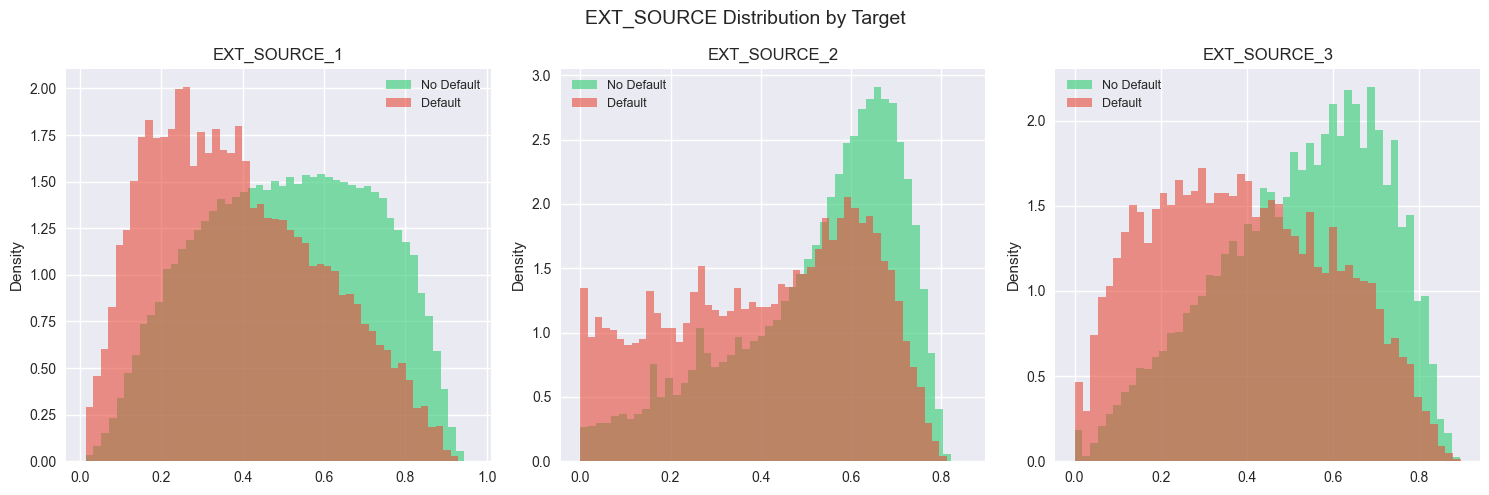

Plot saved to reports/


In [6]:
# EXT_SOURCE features — most predictive in the dataset
ext_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print("=== EXT_SOURCE CORRELATION WITH TARGET ===")
for col in ext_features:
    corr = app_train[col].corr(app_train['TARGET'])
    missing = app_train[col].isnull().sum() / len(app_train) * 100
    median_0 = app_train[app_train['TARGET'] == 0][col].median()
    median_1 = app_train[app_train['TARGET'] == 1][col].median()
    print(f"\n  {col}:")
    print(f"    Correlation with target: {corr:.4f}")
    print(f"    Missing:                 {missing:.1f}%")
    print(f"    Median no default:       {median_0:.3f}")
    print(f"    Median default:          {median_1:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(ext_features):
    data_0 = app_train[app_train['TARGET'] == 0][col].dropna()
    data_1 = app_train[app_train['TARGET'] == 1][col].dropna()
    axes[i].hist(data_0, bins=50, alpha=0.6, color='#2ecc71',
                 label='No Default', density=True)
    axes[i].hist(data_1, bins=50, alpha=0.6, color='#e74c3c',
                 label='Default', density=True)
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('EXT_SOURCE Distribution by Target', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/ext_source_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/")

=== DAYS_EMPLOYED ANOMALY ===
  Max value:  365,243
  Min value:  -17,912

  Rows with value 365243: 55,374 (18.0%)

  Default rate — anomalous rows: 0.054
  Default rate — normal rows:    0.087

  Note: 365243 means unknown employment — will replace with NaN in feature engineering


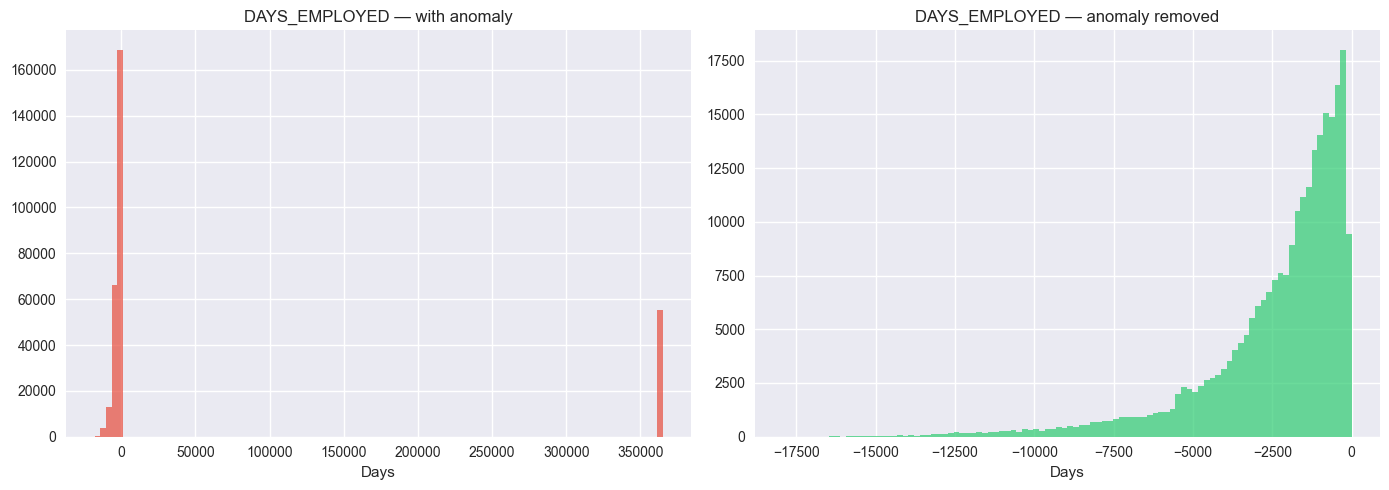

Plot saved to reports/


In [7]:
# DAYS_EMPLOYED anomaly — famous data quality issue in this dataset
print("=== DAYS_EMPLOYED ANOMALY ===")
print(f"  Max value:  {app_train['DAYS_EMPLOYED'].max():,}")
print(f"  Min value:  {app_train['DAYS_EMPLOYED'].min():,}")

anomaly_count = (app_train['DAYS_EMPLOYED'] == 365243).sum()
anomaly_pct = anomaly_count / len(app_train) * 100
print(f"\n  Rows with value 365243: {anomaly_count:,} ({anomaly_pct:.1f}%)")

anomaly_default = app_train[app_train['DAYS_EMPLOYED'] == 365243]['TARGET'].mean()
normal_default  = app_train[app_train['DAYS_EMPLOYED'] != 365243]['TARGET'].mean()
print(f"\n  Default rate — anomalous rows: {anomaly_default:.3f}")
print(f"  Default rate — normal rows:    {normal_default:.3f}")
print(f"\n  Note: 365243 means unknown employment — will replace with NaN in feature engineering")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(app_train['DAYS_EMPLOYED'], bins=100, color='#e74c3c', alpha=0.7)
axes[0].set_title('DAYS_EMPLOYED — with anomaly', fontsize=12)
axes[0].set_xlabel('Days')

clean = app_train[app_train['DAYS_EMPLOYED'] != 365243]['DAYS_EMPLOYED']
axes[1].hist(clean, bins=100, color='#2ecc71', alpha=0.7)
axes[1].set_title('DAYS_EMPLOYED — anomaly removed', fontsize=12)
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.savefig('../reports/days_employed_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to reports/")


=== NAME_CONTRACT_TYPE ===
  Cash loans                               default rate: 0.083  count: 278,232
  Revolving loans                          default rate: 0.055  count: 29,279

=== CODE_GENDER ===
  M                                        default rate: 0.101  count: 105,059
  F                                        default rate: 0.070  count: 202,448
  XNA                                      default rate: 0.000  count: 4

=== NAME_INCOME_TYPE ===
  Maternity leave                          default rate: 0.400  count: 5
  Unemployed                               default rate: 0.364  count: 22
  Working                                  default rate: 0.096  count: 158,774
  Commercial associate                     default rate: 0.075  count: 71,617
  State servant                            default rate: 0.058  count: 21,703
  Pensioner                                default rate: 0.054  count: 55,362
  Businessman                              default rate: 0.000  count: 10
  S

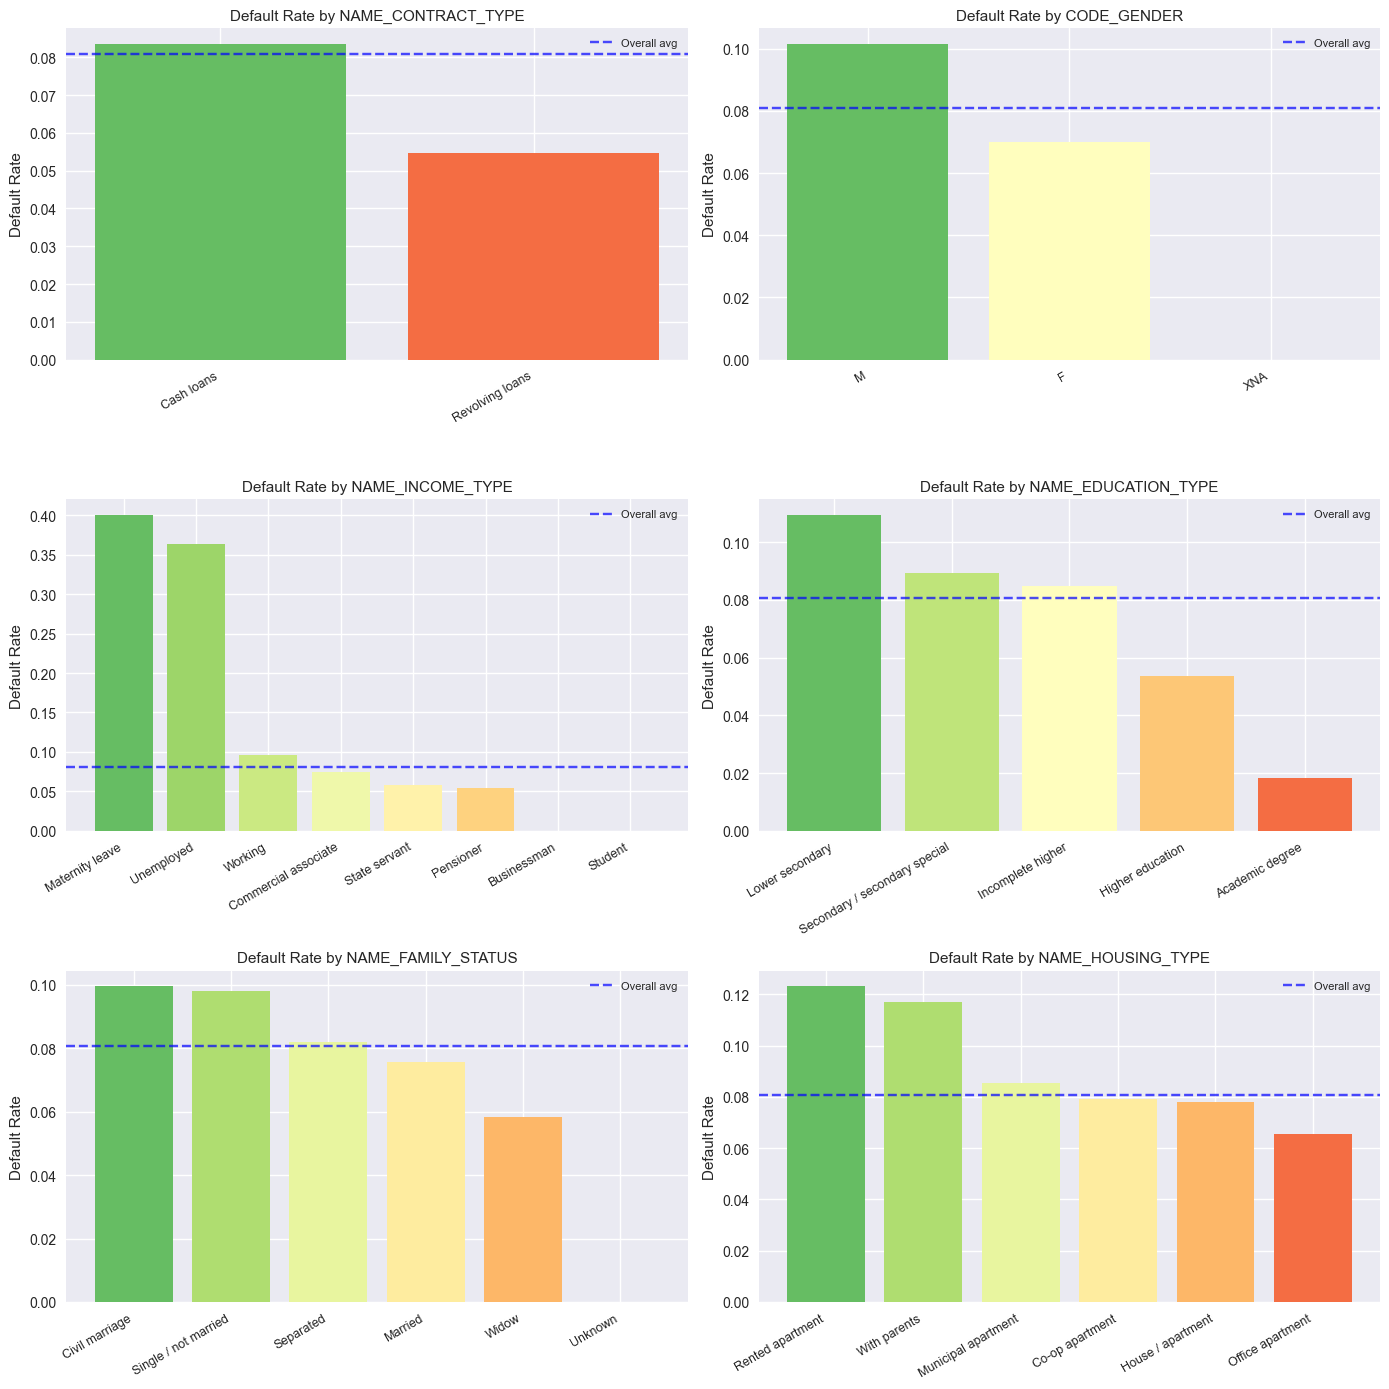


Plot saved to reports/


In [8]:
# Default rate by key categorical features
cat_features = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    default_rate = app_train.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    
    print(f"\n=== {col} ===")
    for val in default_rate.index:
        count = app_train[col].value_counts()[val]
        print(f"  {val:<40} default rate: {default_rate[val]:.3f}  count: {count:,}")
    
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(default_rate)))
    axes[i].bar(range(len(default_rate)), default_rate.values, color=colors)
    axes[i].set_xticks(range(len(default_rate)))
    axes[i].set_xticklabels(default_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'Default Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Default Rate')
    axes[i].axhline(y=app_train['TARGET'].mean(), color='blue',
                    linestyle='--', alpha=0.7, label='Overall avg')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved to reports/")

In [9]:
# Load each supplementary table one at a time
# Print summary then delete from memory immediately
table_info = {}

tables_to_load = {
    'bureau':               '../data/raw/bureau.csv',
    'bureau_balance':       '../data/raw/bureau_balance.csv',
    'previous_application': '../data/raw/previous_application.csv',
    'installments':         '../data/raw/installments_payments.csv',
    'credit_card':          '../data/raw/credit_card_balance.csv',
    'pos_cash':             '../data/raw/POS_CASH_balance.csv',
}

for name, path in tables_to_load.items():
    df = reduce_memory(pd.read_csv(path))
    info = {
        'rows':    len(df),
        'cols':    len(df.columns),
        'memory':  df.memory_usage().sum() / 1e6,
        'columns': list(df.columns[:5])
    }
    table_info[name] = info
    print(f"{name:<25} {info['rows']:>10,} rows  "
          f"{info['cols']:>3} cols  "
          f"{info['memory']:>7.1f} MB")
    del df
    gc.collect()

print(f"\n{'='*60}")
print(f"Main table:              {len(app_train):>10,} rows")
print(f"\nNote: All supplementary tables join to app_train via SK_ID_CURR")
print(f"We will aggregate them in feature engineering notebook")

bureau                     1,716,428 rows   17 cols    166.5 MB
bureau_balance            27,299,925 rows    3 cols    354.9 MB
previous_application       1,670,214 rows   37 cols    374.1 MB
installments              13,605,401 rows    8 cols    517.0 MB
credit_card                3,840,312 rows   23 cols    503.1 MB
pos_cash                  10,001,358 rows    8 cols    290.0 MB

Main table:                 307,511 rows

Note: All supplementary tables join to app_train via SK_ID_CURR
We will aggregate them in feature engineering notebook


## EDA Summary — Key Findings

### Target Variable
- Dataset is heavily imbalanced — 91.9% no default, 8.1% default
- Imbalance ratio 11.4:1 — we will use SMOTE + class weights to handle this

### Missing Values
- 67 columns have missing values, 41 above 50%
- Building-level features (COMMONAREA, NONLIVINGAPARTMENTS) are missing for ~70% of applicants
- Strategy — create missingness indicator flags + impute with median

### Most Predictive Features
- EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 are strongest signals (correlation ~-0.16 to -0.18)
- Higher external credit score = lower default risk
- DAYS_BIRTH (age) is most risky numerical feature — younger applicants default more

### Data Quality Issues
- DAYS_EMPLOYED has 55,374 rows (18%) with anomalous value 365243
- These represent unknown employment — will replace with NaN + flag column

### Categorical Insights
- Males default at 10.1% vs females 7.0%
- Unemployed (36.4%) and Maternity leave (40%) have highest default rates
- Lower secondary education has highest default rate among education levels (10.9%)

### Supplementary Tables
- 6 supplementary tables with up to 27M rows
- All join to main table via SK_ID_CURR
- Will aggregate per customer in feature engineering notebook

### Next Step
- Feature engineering — aggregate supplementary tables + create ratio features